# Baseline CNN — WaRP-C Waste Classification
 El Mehdi Ziate  

### What this notebook does
Trains and evaluates a simple 4-block CNN as the **lower-bound baseline**.  
Every other model (ResNet50, EfficientNet, Swin, ConvNeXt…) is expected to beat this.

### Reference
Architecture follows the baseline CNN used in:  
*Ogrezeanu et al. (2024), "Automated Waste Sorting: A Comprehensive Approach Using Deep Learning", IEEE MED 2024.*  


## Imports & Setup

In [1]:
import sys, json, time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

root = Path.cwd()
while not (root / 'Pipeline_').exists() and root != root.parent:
    root = root.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from Pipeline_.preprocessor import WaRPPreprocessor, WARP_MEAN, WARP_STD
from Models.CNN import CNNModel

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device  : {DEVICE}')
print(f'PyTorch : {torch.__version__}')

Device  : cuda
PyTorch : 2.5.1+cu121


## Data Pipeline

In [2]:
pp = WaRPPreprocessor(
    raw_root       = root / 'Dataset/raw/Warp-C',
    processed_root = root / 'Dataset/processed',
    stats_file     = root / 'Dataset/dataset_stats.json',
    batch_size     = 32,
    num_workers    = 4,
)

train_loader, test_loader = pp.get_loaders(model_type='cnn')

criterion = nn.CrossEntropyLoss()

CLASS_NAMES = sorted(d.name for d in (root / 'Dataset/processed/train').iterdir() if d.is_dir())
NUM_CLASSES = len(CLASS_NAMES)

print(f'Classes : {NUM_CLASSES}')
print(f'Train batches plain: {len(train_loader)}')
print(f'Test  batches : {len(test_loader)}')

[get_loaders] model='cnn'
  sampler=False  minority_aug=False  mixup=False  pipeline='cnn'
  train=273 batches  test=49 batches  sampler=Uniform (shuffle)
Classes : 28
Train batches plain: 273
Test  batches : 49


## Model

In [3]:
model = CNNModel(num_classes=NUM_CLASSES, dropout_p=0.5).to(DEVICE)

total_params = model.count_parameters()
print(f'Total trainable parameters: {total_params:,}')

# verify forward pass shape
dummy = torch.zeros(2, 3, 224, 224).to(DEVICE)
with torch.no_grad():
    out = model(dummy)
print(f'\nInput  shape : {dummy.shape}')
print(f'Output shape : {out.shape}   ← should be (2, {NUM_CLASSES})')

Total trainable parameters: 425,404

Input  shape : torch.Size([2, 3, 224, 224])
Output shape : torch.Size([2, 28])   ← should be (2, 28)


## Training Configuration

- **Optimiser:** AdamW : Adam with decoupled weight decay 
- **Scheduler:** CosineAnnealingLR : smoothly reduces LR to near zero 
- **Epochs:** 30 : for a baseline CNN to converge without overfitting

In [4]:
NUM_EPOCHS = 60
LR = 1e-3
optimiser  = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=NUM_EPOCHS)

print(f'Optimiser : AdamW  lr={LR}  weight_decay=1e-4')
print(f'Scheduler : CosineAnnealingLR  T_max={NUM_EPOCHS}')
print(f'Epochs    : {NUM_EPOCHS}')

Optimiser : AdamW  lr=0.001  weight_decay=1e-4
Scheduler : CosineAnnealingLR  T_max=60
Epochs    : 60


## Training Loop

In [5]:
train_losses, train_accs = [], []
test_accs = []

best_test_acc = 0.0
best_path = root / 'Models/weights/cnn_baseline_best.pth'
best_path.parent.mkdir(parents=True, exist_ok=True)

for epoch in range(1, NUM_EPOCHS + 1):
    # Training
    model.train()
    epoch_loss, correct, total = 0.0, 0, 0
    t0 = time.time()

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimiser.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimiser.step()

        epoch_loss += loss.item() * images.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += images.size(0)

    scheduler.step()

    avg_loss = epoch_loss / total
    avg_train_acc = 100.0 * correct / total
    train_losses.append(avg_loss)
    train_accs.append(avg_train_acc)

    #Evaluation
    model.eval()
    test_correct, test_total = 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            logits = model(images)
            preds = logits.argmax(dim=1)

            test_correct += (preds == labels).sum().item()
            test_total += labels.size(0)

    avg_test_acc = 100.0 * test_correct / test_total
    test_accs.append(avg_test_acc)

    if avg_test_acc > best_test_acc:
        best_test_acc = avg_test_acc
        torch.save(model.state_dict(), best_path)

    elapsed = time.time() - t0

    print(
        f'Epoch {epoch:3d}/{NUM_EPOCHS} | '
        f'Loss: {avg_loss:.4f} | '
        f'Train Acc: {avg_train_acc:.2f}% | '
        f'Test Acc: {avg_test_acc:.2f}% | '
        f'LR: {scheduler.get_last_lr()[0]:.6f} | '
        f'Time: {elapsed:.1f}s'
    )

print(f'\nBest test accuracy: {best_test_acc:.2f}%')
print(f'Best weights saved → {best_path}')

Epoch   1/60 | Loss: 2.8980 | Train Acc: 18.88% | Test Acc: 22.31% | LR: 0.000999 | Time: 74.1s
Epoch   2/60 | Loss: 2.5681 | Train Acc: 24.55% | Test Acc: 24.95% | LR: 0.000997 | Time: 22.2s
Epoch   3/60 | Loss: 2.4213 | Train Acc: 27.16% | Test Acc: 26.50% | LR: 0.000994 | Time: 20.5s
Epoch   4/60 | Loss: 2.3412 | Train Acc: 28.89% | Test Acc: 32.75% | LR: 0.000989 | Time: 19.1s
Epoch   5/60 | Loss: 2.2787 | Train Acc: 30.84% | Test Acc: 34.88% | LR: 0.000983 | Time: 19.6s
Epoch   6/60 | Loss: 2.2117 | Train Acc: 31.55% | Test Acc: 32.88% | LR: 0.000976 | Time: 19.0s
Epoch   7/60 | Loss: 2.1739 | Train Acc: 32.47% | Test Acc: 34.43% | LR: 0.000967 | Time: 19.1s
Epoch   8/60 | Loss: 2.1257 | Train Acc: 33.63% | Test Acc: 38.04% | LR: 0.000957 | Time: 19.2s
Epoch   9/60 | Loss: 2.0837 | Train Acc: 34.83% | Test Acc: 36.69% | LR: 0.000946 | Time: 19.4s
Epoch  10/60 | Loss: 2.0635 | Train Acc: 35.13% | Test Acc: 36.81% | LR: 0.000933 | Time: 19.6s
Epoch  11/60 | Loss: 2.0240 | Train Acc:

##  Plot Training Curves

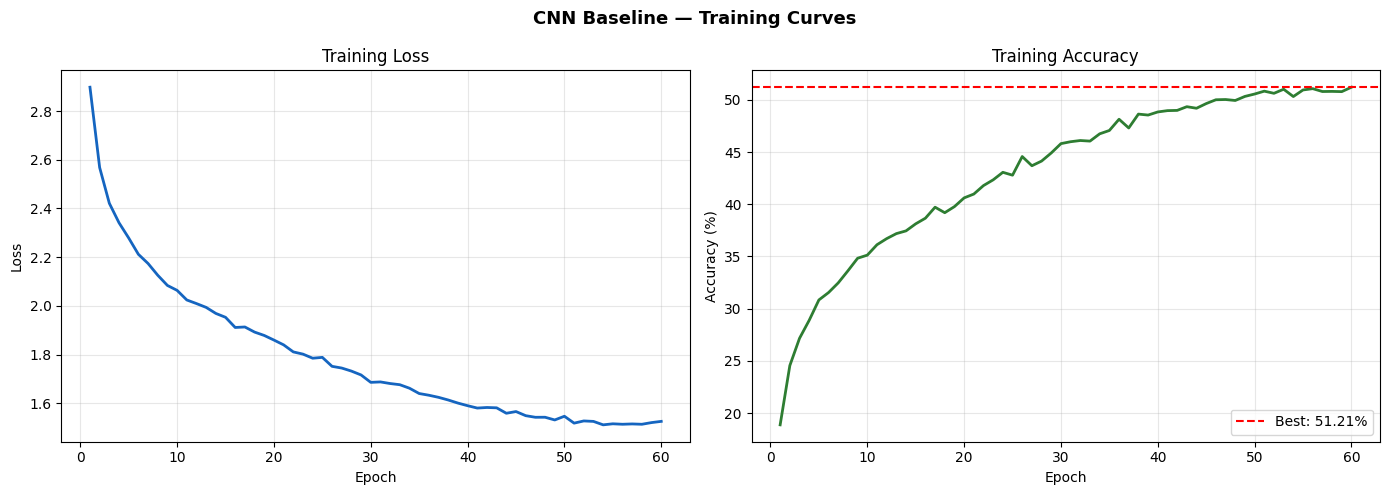

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CNN Baseline — Training Curves', fontsize=13, fontweight='bold')

epochs = range(1, NUM_EPOCHS + 1)

ax1.plot(epochs, train_losses, '#1565C0', linewidth=2)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Training Loss'); ax1.grid(alpha=0.3)

ax2.plot(epochs, train_accs, '#2E7D32', linewidth=2)
ax2.axhline(max(train_accs), color='red', linestyle='--',
            label=f'Best: {max(train_accs):.2f}%')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training Accuracy'); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(root / 'Dataset/figures/cnn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Evaluation on Test Set

In [7]:
# load best weights
model.load_state_dict(torch.load(best_path, map_location=DEVICE))

model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        preds  = model(images).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)


top1_acc = (all_preds == all_labels).mean() * 100
print(f'Test Top-1 Accuracy : {top1_acc:.2f}%')


C:\Users\El Mehdi Ziate\AppData\Local\Temp\ipykernel_15784\602015995.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_path, map_loca

Test Top-1 Accuracy : 53.13%


## Classification Report (per-class F1)

In [8]:
print(classification_report(all_labels, all_preds,
                             target_names=CLASS_NAMES,
                             digits=3))

                         precision    recall  f1-score   support

            bottle-blue      0.560     0.452     0.500       104
       bottle-blue-full      0.576     0.442     0.500        43
          bottle-blue5l      0.500     0.486     0.493        72
     bottle-blue5l-full      0.625     0.208     0.312        24
            bottle-dark      0.691     0.895     0.780        95
       bottle-dark-full      0.679     0.559     0.613        34
           bottle-green      0.600     0.770     0.675        74
      bottle-green-full      0.677     0.618     0.646        34
            bottle-milk      0.329     0.456     0.382        57
       bottle-milk-full      0.625     0.238     0.345        21
      bottle-multicolor      0.625     0.179     0.278        28
bottle-multicolorv-full      0.769     0.476     0.588        21
             bottle-oil      0.000     0.000     0.000        48
        bottle-oil-full      0.000     0.000     0.000         8
          bottle-transp 

c:\Users\El Mehdi Ziate\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\El Mehdi Ziate\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\El Mehdi Ziate\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavi

## 8 — Confusion Matrix

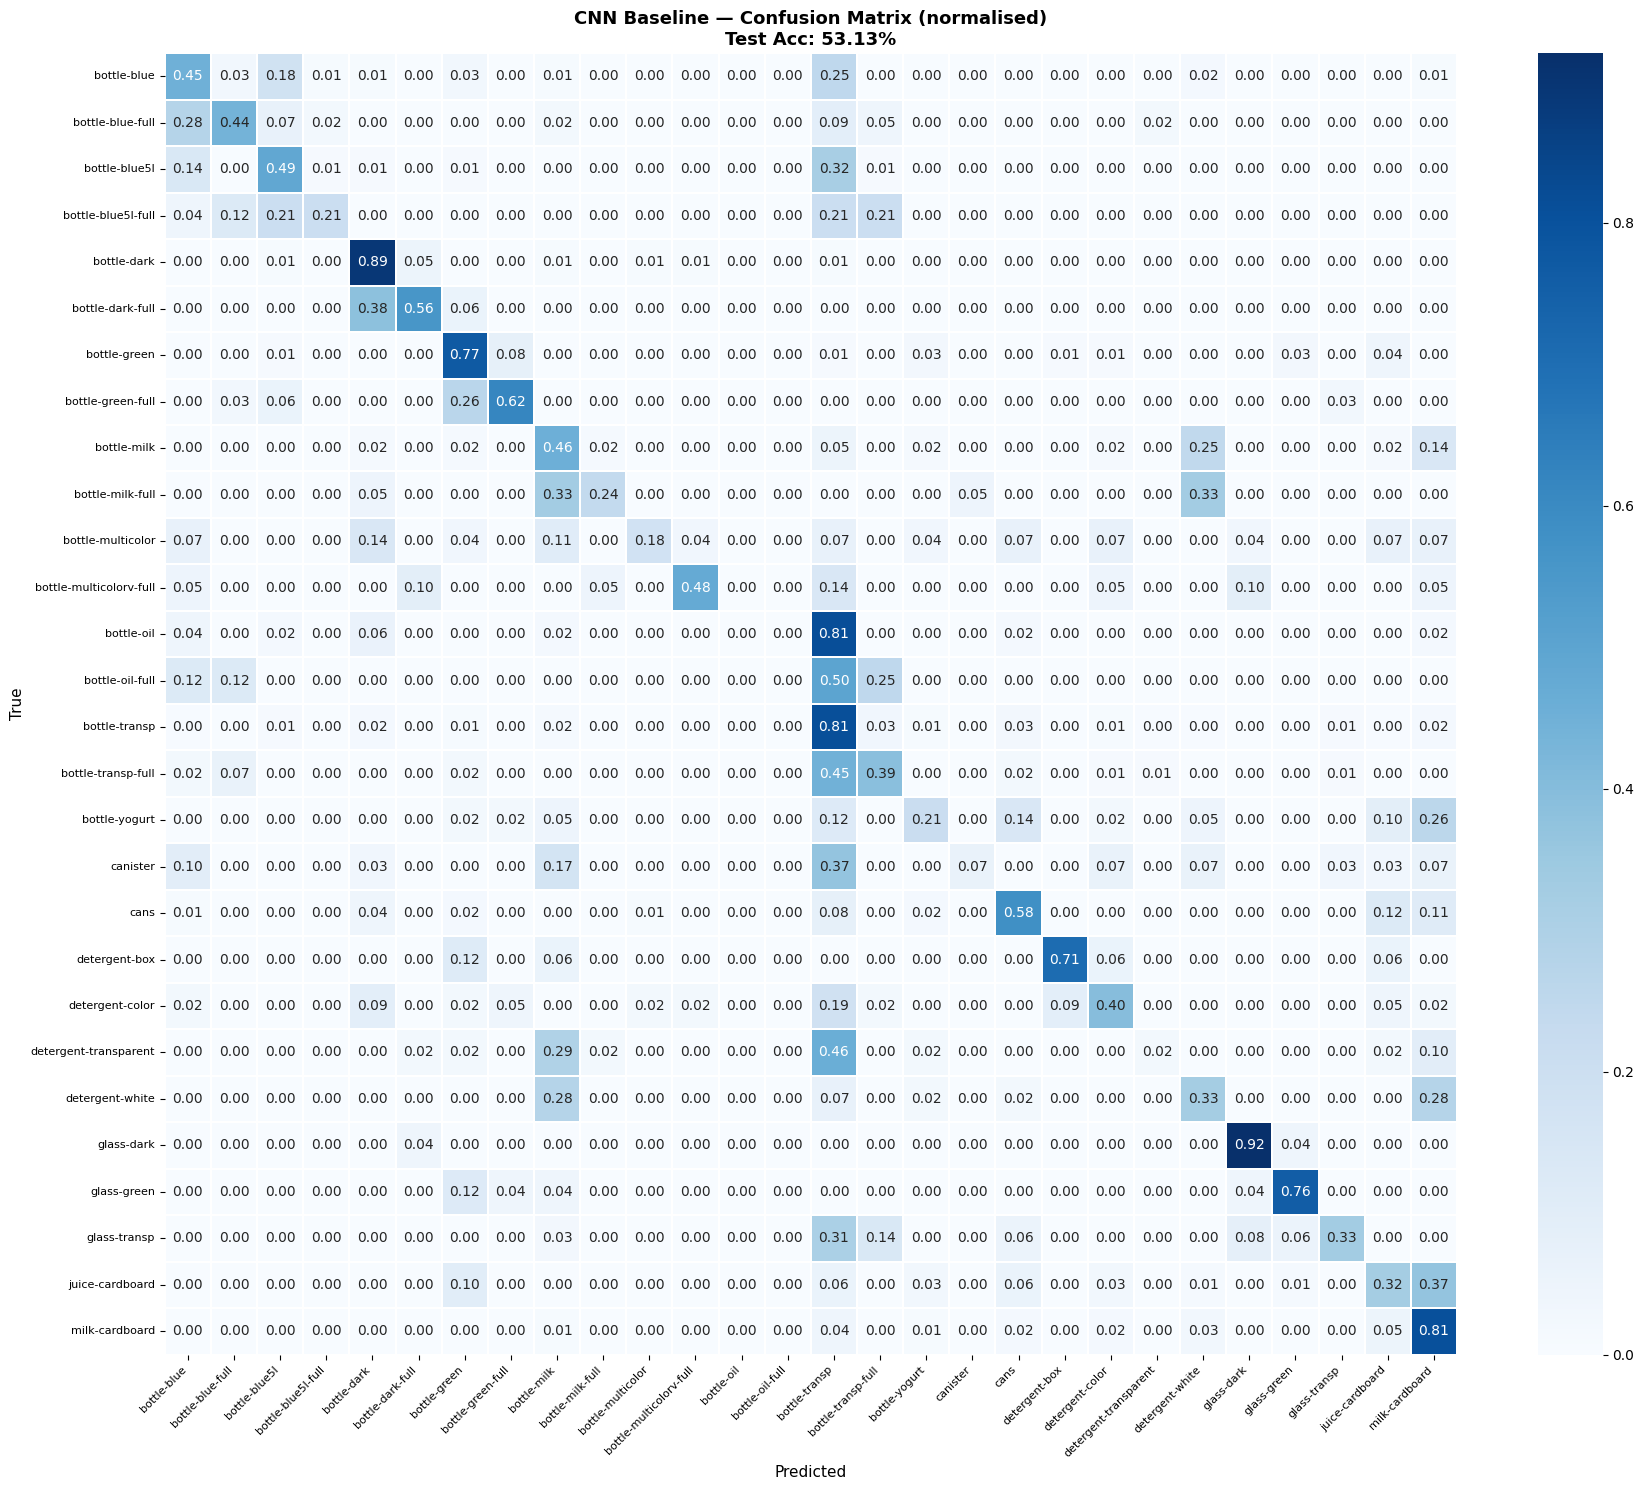

Saved → Dataset/figures/cnn_confusion_matrix.png


In [9]:
cm = confusion_matrix(all_labels, all_preds)
# normalise by true class (row-wise) so colour shows recall per class
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.3, ax=ax)
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('True', fontsize=11)
ax.set_title(f'CNN Baseline — Confusion Matrix (normalised)\nTest Acc: {top1_acc:.2f}%',
             fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
fig.savefig(root / 'Dataset/figures/cnn_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → Dataset/figures/cnn_confusion_matrix.png')

## TTA Evaluation

In [ ]:
from PIL import Image

tta_pipelines = pp.get_tta_transforms()
mean_t = torch.tensor(WARP_MEAN).view(3,1,1)
std_t  = torch.tensor(WARP_STD).view(3,1,1)

model.eval()
tta_preds, tta_labels = [], []

# collect test image paths from the Dataset object
test_samples = test_loader.dataset.samples   # list of (Path, label)

with torch.no_grad():
    for img_path, label in test_samples:
        img   = Image.open(img_path).convert('RGB')
        probs = []
        for tfm in tta_pipelines:
            tensor = tfm(img).unsqueeze(0).to(DEVICE)
            probs.append(model(tensor).softmax(dim=1))
        final_pred = torch.stack(probs).mean(0).argmax().item()
        tta_preds.append(final_pred)
        tta_labels.append(label)

tta_acc = (np.array(tta_preds) == np.array(tta_labels)).mean() * 100
print(f'TTA Test Accuracy : {tta_acc:.2f}%')
print(f'Standard Test Acc : {top1_acc:.2f}%')
print(f'TTA gain          : +{tta_acc - top1_acc:.2f}%')

## Summary for Report

In [11]:
print('=' * 55)
print('  CNN BASELINE — Final Results')
print('=' * 55)
print(f'  Architecture    : 4-block CNN + GAP + FC')
print(f'  Parameters      : {model.count_parameters():,}')
print(f'  Epochs trained  : {NUM_EPOCHS}')
print(f'  Test accuracy   : {top1_acc:.2f}%')
print(f'  Weights saved   : Models/weights/cnn_baseline_best.pth')
print('=' * 55)
print('  This is the lower bound. All other models should beat this.')
print('  Reference: Ogrezeanu et al. (2024) IEEE MED 2024')
print('=' * 55)

  CNN BASELINE — Final Results
  Architecture    : 4-block CNN + GAP + FC
  Parameters      : 425,404
  Epochs trained  : 60
  Test accuracy   : 53.13%
  Weights saved   : Models/weights/cnn_baseline_best.pth
  This is the lower bound. All other models should beat this.
  Reference: Ogrezeanu et al. (2024) IEEE MED 2024
